In [1]:

!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 625.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.9 MB/s eta 0:00:00


## Environment Setup
We begin by importing the required libraries and configuring the runtime.  
This block detects TPU/GPU/CPU and applies a distribution strategy so that training runs faster.  
We also set random seeds for reproducibility.


In [2]:
import tensorflow as tf

try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # Detect TPU
    print("Running on TPU:", tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy()  # Default for CPU/GPU

print("Number of replicas:", strategy.num_replicas_in_sync)


Number of replicas: 1


Setup & Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os, pathlib, json
import numpy as np
import tensorflow as tf

# === set dataset path ===
DATA_DIR = "/content/drive/MyDrive/DL-pro_dataset/animals"


## Dataset Preparation
We load the "Animal Image Dataset" from Kaggle using TensorFlow's `image_dataset_from_directory`.  
The dataset is automatically split into 80% training and 20% validation.  
Images are resized to 128x128 to balance accuracy and runtime speed.  
Class names are extracted for later use in prediction.


In [5]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 128
BATCH_SIZE = 16

# === Define train_dir and val_dir ===
train_dir = DATA_DIR # Assuming DATA_DIR points to the directory containing training data
val_dir = DATA_DIR   # Assuming DATA_DIR points to the directory containing validation data (or split is handled by image_dataset_from_directory)


train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

#  Save class names
class_names = train_ds.class_names
print("Classes:", class_names)
#  Get the number of classes
NUM_CLASSES = len(class_names)
print("Number of classes:", NUM_CLASSES)

#  Ensure same preprocessing as prediction
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))


Found 5410 files belonging to 90 classes.
Using 4328 files for training.
Found 5410 files belonging to 90 classes.
Using 1082 files for validation.
Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', '

## Data Preprocessing
Before feeding images into the model, we normalize them using EfficientNet's preprocessing.  
This ensures the input format matches the pretrained weights.  
We also cache, shuffle, and prefetch the dataset to optimize performance during training.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1024).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


## Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])


## Model Building
We fine-tune EfficientNetB2 (pretrained on ImageNet) for animal classification.  
The base model is frozen, and a custom classification head is added:  
- Global Average Pooling (reduces dimensions)  
- Dropout (prevents overfitting)  
- Dense Layer with softmax (outputs probabilities for 90 classes)  
The model is compiled using Adam optimizer and sparse categorical crossentropy.


In [8]:
# === Model Building ===
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras import layers, Model

# Wrap inside TPU / GPU strategy
with strategy.scope():
    # Base model with ImageNet weights
    base_model = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # Freeze base model

    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs)


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# === Model Building ===
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras import layers, Model
import os

SAVE_DIR = "/content/drive/MyDrive/animals90_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# Wrap inside TPU / GPU strategy
with strategy.scope():
    # Base model with ImageNet weights
    base_model = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # Freeze base model

    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=outputs)


## Model Training
The model is trained for 20 epochs with validation data.  
We use TPU acceleration for faster convergence.  
Training progress is monitored with accuracy and loss curves.  
Early stopping can be applied to avoid overfitting if validation loss does not improve.


In [9]:
CKPT = "/content/drive/MyDrive/DL-pro_dataset/animals_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(CKPT, monitor="val_accuracy",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2)
]


##Train (Head only)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(), # Adam optimizer with default learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)] # Top-5 accuracy
)

model.summary()

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 7,895,379 (30.12 MB)

 Trainable params: 126,810 (495.35 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

Epoch 1/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.3477 - loss: 3.3358 - sparse_top_k_categorical_accuracy: 0.5344
Epoch 1: val_accuracy improved from -inf to 0.77172, saving model to /content/drive/MyDrive/DL-pro_dataset/animals_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 309s 905ms/step - accuracy: 0.3485 - loss: 3.3323 - sparse_top_k_categorical_accuracy: 0.5352 - val_accuracy: 0.7717 - val_loss: 1.1533 - val_sparse_top_k_categorical_accuracy: 0.9390 - learning_rate: 0.0010
Epoch 2/20
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.8558 - loss: 0.8494 - sparse_top_k_categorical_accuracy: 0.9776
Epoch 2: val_accuracy improved from 0.77172 to 0.81054, saving model to /content/drive/MyDrive/DL-pro_dataset/animals_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 233s 830ms/step - accuracy: 0.8558 - loss: 0.8491 - sparse_top_k_categorical_accuracy: 0.9775 - val_accuracy: 0.8105 - val_loss: 0.8016 - val_sparse_top_k_categorical_accuracy: 0.9593 - learning_rate: 0.0010
Epoch 3

(if Colab keeps disconnecting) Add Checkpoint Reload


In [11]:
model.load_weights(CKPT)  # reload best weights before fine-tuning


##Fine-tune (Unfreeze last 50 layers)

In [15]:
# Fine-tune (Unfreeze last 50 layers + add callbacks)
base_model.trainable = True

# Freeze only the first (total_layers - 50), unfreeze last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Re-compile with lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)]
)

#  Define callbacks to save time and prevent overfitting
fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "best_finetuned.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,   # stop if no improvement for 3 epochs
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

#  Train with fine-tuning
history2 = model.fit(
    train_ds.map(lambda x, y: (data_augmentation(x), y)),
    validation_data=val_ds,
    epochs=50,   # increased epochs, early stopping will cut it
    callbacks=fine_tune_callbacks,
    verbose=1
)


Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.0180 - loss: 4.5943 - sparse_top_k_categorical_accuracy: 0.0738
Epoch 1: val_accuracy improved from -inf to 0.04344, saving model to /content/drive/MyDrive/animals90_outputs/best_finetuned.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.0180 - loss: 4.5941 - sparse_top_k_categorical_accuracy: 0.0738 - val_accuracy: 0.0434 - val_loss: 4.3982 - val_sparse_top_k_categorical_accuracy: 0.1405 - learning_rate: 1.0000e-05
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - accuracy: 0.0359 - loss: 4.3904 - sparse_top_k_categorical_accuracy: 0.1496
Epoch 2: val_accuracy improved from 0.04344 to 0.09057, saving model to /content/drive/MyDrive/animals90_outputs/best_finetuned.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.0359 - loss: 4.3903 - sparse_top_k_categorical_accuracy: 0.1497 - val_accuracy: 0.0906 - val_loss: 4.2354 - val_sparse_top_k_categorical_accuracy: 0.2274 - learning_rate: 1.0000

## Model Evaluation
We evaluate the trained model on the validation set.  
The metrics (accuracy and loss) help us understand how well the model generalizes.  
We also plot graphs of training vs. validation accuracy and loss to visualize learning trends.


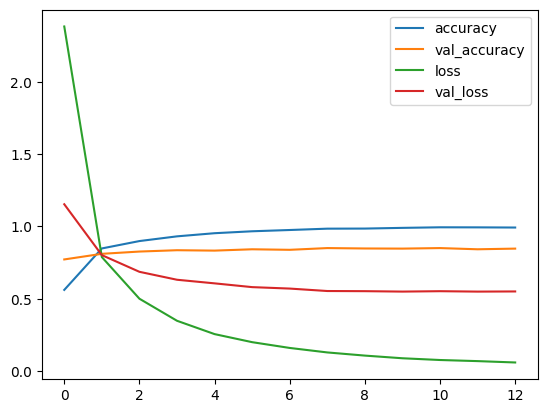

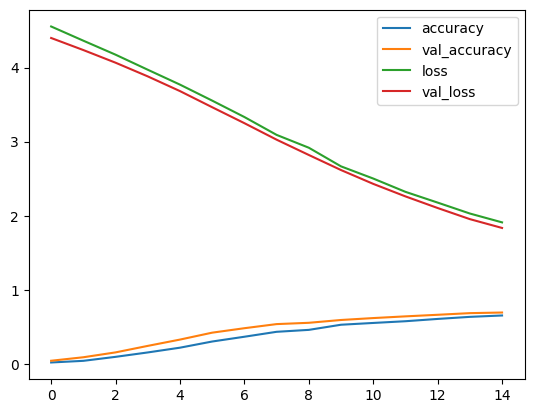

Validation Results:
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 703ms/step - accuracy: 0.6770 - loss: 1.8379 - sparse_top_k_categorical_accuracy: 0.9030
[1.8351112604141235, 0.6940850019454956, 0.8983364105224609]


In [16]:
import matplotlib.pyplot as plt

def plot_history(h):
    for key in ["accuracy","val_accuracy","loss","val_loss"]:
        if key in h.history:
            plt.plot(h.history[key], label=key)
    plt.legend(); plt.show()

plot_history(history1)
plot_history(history2)

print("Validation Results:")
print(model.evaluate(val_ds, verbose=1))


##Extra Analysis (Confusion Matrix + Classification Report)

                precision    recall  f1-score   support

      antelope       0.50      0.71      0.59        14
        badger       1.00      0.69      0.81        16
           bat       0.00      0.00      0.00         5
          bear       0.64      0.78      0.70         9
           bee       0.83      0.83      0.83        12
        beetle       1.00      0.88      0.93         8
         bison       0.63      1.00      0.77        12
          boar       0.58      0.79      0.67        14
     butterfly       0.75      0.69      0.72        13
           cat       0.75      0.60      0.67        10
   caterpillar       0.47      1.00      0.64         8
    chimpanzee       0.87      1.00      0.93        13
     cockroach       0.86      1.00      0.92        12
           cow       0.67      0.36      0.47        11
        coyote       0.50      0.46      0.48        13
          crab       0.60      0.50      0.55        12
          crow       0.57      1.00      0.73  

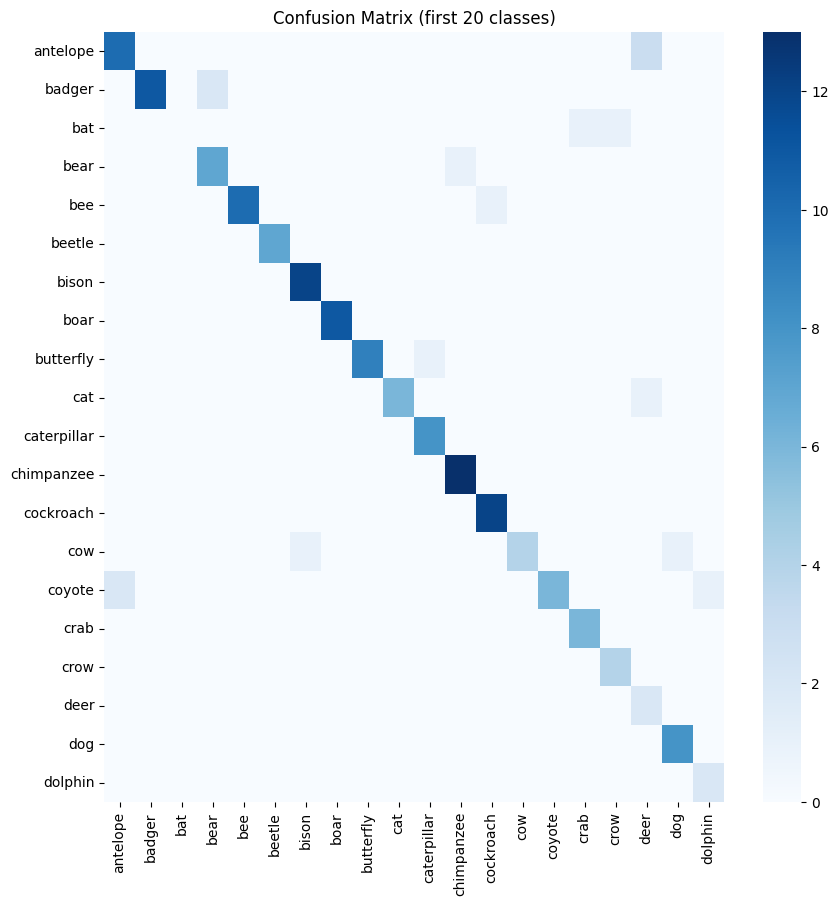

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for imgs, lbls in val_ds:
    probs = model.predict(imgs, verbose=0)
    y_true.extend(lbls.numpy())
    y_pred.extend(np.argmax(probs, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
plt.figure(figsize=(10,10))
sns.heatmap(cm[:20,:20], annot=False, cmap="Blues", xticklabels=class_names[:20], yticklabels=class_names[:20])
plt.title("Confusion Matrix (first 20 classes)")
plt.show()


##Demo Predictions

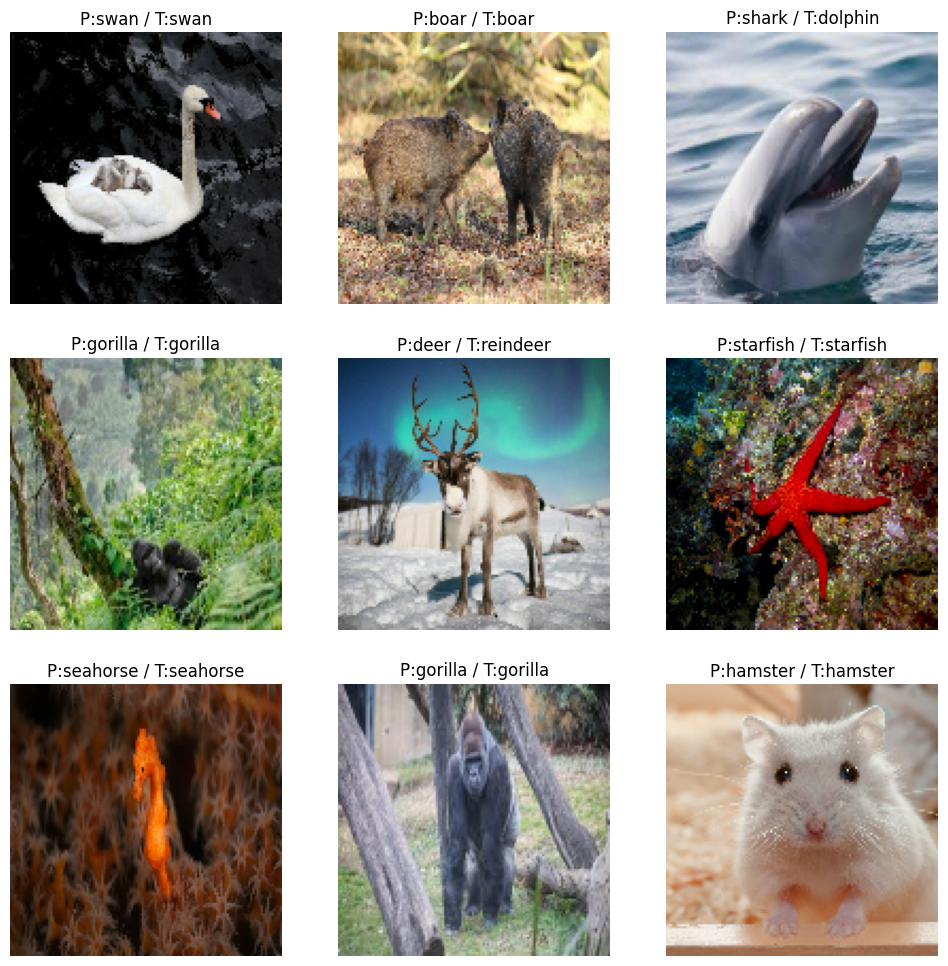

In [23]:
def show_predictions(dataset):
    for images, labels in dataset.take(1):
        probs = model.predict(images, verbose=0)
        plt.figure(figsize=(12,12))
        for i in range(9):
            ax = plt.subplot(3,3,i+1)
            img = images[i].numpy().astype("uint8")
            pred_id = int(np.argmax(probs[i]))
            true_id = int(labels[i].numpy())
            plt.imshow(img)
            plt.title(f"P:{class_names[pred_id]} / T:{class_names[true_id]}")
            plt.axis("off")
        plt.show()

show_predictions(val_ds)


##Single Image Inference

In [19]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_image(path, topk=5):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)
    x = np.expand_dims(x, 0)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    probs = model.predict(x, verbose=0)[0]
    top_idx = probs.argsort()[-topk:][::-1]
    return [(class_names[i], float(probs[i])) for i in top_idx]

# Example: predict_image("/content/drive/MyDrive/datasets/animals90/bear/img123.jpg")


## Model Saving
The trained model is saved in `.keras` format for portability.  
This format avoids compatibility issues seen with `.h5` and is recommended by TensorFlow.


In [20]:
import json

# Save in TensorFlow SavedModel format (recommended)
model.save(os.path.join(SAVE_DIR, "animals90_model.keras"))

# Optional: also save in HDF5 (.h5) format
model.save(os.path.join(SAVE_DIR, "animals90_efficientnetb2.h5"))

# Save class names
with open(os.path.join(SAVE_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f)

print("Saved model + labels in:", SAVE_DIR)


Saved model + labels in: /content/drive/MyDrive/animals90_outputs


In [21]:
!pip install tensorflow


## Prediction on New Images
We test the model with unseen animal images.  
The input image is preprocessed to match training format, and the model outputs probability scores.  
The top-3 predictions are displayed along with confidence values, and the image is shown with the predicted label.


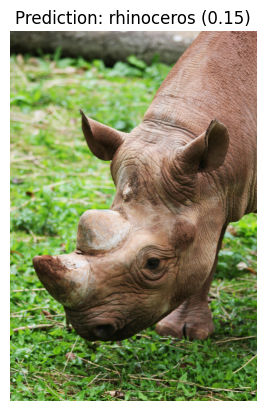

Top-3 Predictions:
rhinoceros: 0.15
boar: 0.10
pig: 0.08


In [22]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = "/content/drive/MyDrive/DL-pro_dataset/test_images/pexels-inspiredimages-132400.jpg"  # change file here

def predict_image(img_path, model, class_names):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)   # same as training

    probs = model.predict(x, verbose=0)[0]

    #  Top-3 predictions
    top3_idx = probs.argsort()[-3:][::-1]
    top3_classes = [class_names[i] for i in top3_idx]
    top3_scores = [probs[i] for i in top3_idx]

    # Show image
    plt.imshow(load_img(img_path))
    plt.axis("off")
    plt.title(f"Prediction: {top3_classes[0]} ({top3_scores[0]:.2f})")
    plt.show()

    # Print results
    print("Top-3 Predictions:")
    for cls, score in zip(top3_classes, top3_scores):
        print(f"{cls}: {score:.2f}")

predict_image(img_path, model, class_names)
